# Transfer Learning com ResNet50 em CIFAR-10 e EuroSAT

Notebook preparado para comparar duas estratégias de transfer learning com uma ResNet50 pré-treinada em ImageNet: feature extraction e fine-tuning.

Objetivo do experimento: avaliar como a proximidade entre o domínio fonte (ImageNet) e o domínio alvo afeta a transferibilidade em um cenário próximo (CIFAR-10) e em um cenário distante (EuroSAT).

Este arquivo foi montado para execução no Colab com GPU, mas não foi executado aqui.

In [1]:

import os
import random
import time
from contextlib import nullcontext
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

DATA_ROOT = Path('/content/data')
OUTPUT_ROOT = Path('/content/transfer_learning_results')
DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 10
PATIENCE = 3
WEIGHT_DECAY = 1e-4
HEAD_LR = 1e-3
BLOCK_LR = 1e-4
LABEL_SMOOTHING = 0.1
DROP_OUT = 0.3
IMAGE_SIZE = 224
NUM_WORKERS = 2 if os.name == 'nt' else min(4, os.cpu_count() or 2)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device: {DEVICE}')
print(f'Using AMP: {USE_AMP}')

Device: cuda
Using AMP: True


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
EUROSAT_FALLBACK_CLASSES = [
    'AnnualCrop',
    'Forest',
    'HerbaceousVegetation',
    'Highway',
    'Industrial',
    'Pasture',
    'PermanentCrop',
    'Residential',
    'River',
    'SeaLake',
]

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


def get_targets(dataset) -> np.ndarray:
    if hasattr(dataset, 'targets'):
        return np.asarray(dataset.targets)
    if hasattr(dataset, 'labels'):
        return np.asarray(dataset.labels)
    if hasattr(dataset, 'samples'):
        return np.asarray([sample[1] for sample in dataset.samples])
    raise AttributeError('Não foi possível localizar os alvos do dataset.')


def get_class_names(dataset_name: str, dataset_obj=None) -> list[str]:
    if dataset_obj is not None and hasattr(dataset_obj, 'classes'):
        return list(dataset_obj.classes)
    if dataset_name == 'eurosat':
        return EUROSAT_FALLBACK_CLASSES
    raise AttributeError('Não foi possível localizar os nomes das classes.')


def build_transforms(dataset_name: str, train: bool):
    if dataset_name == 'cifar10':
        if train:
            return transforms.Compose([
                transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
                transforms.RandomCrop(IMAGE_SIZE),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        return transforms.Compose([
            transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
            transforms.CenterCrop(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    if dataset_name == 'eurosat':
        if train:
            return transforms.Compose([
                transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0), interpolation=InterpolationMode.BILINEAR),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(90),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        return transforms.Compose([
            transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
            transforms.CenterCrop(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    raise ValueError(f'Dataset não suportado: {dataset_name}')


def stratified_split_indices(targets: np.ndarray, test_size: float, seed: int = SEED):
    indices = np.arange(len(targets))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        stratify=targets,
        random_state=seed,
    )
    return np.asarray(train_idx), np.asarray(test_idx)


def build_datasets(dataset_name: str, data_root: Path = DATA_ROOT, seed: int = SEED):
    if dataset_name == 'cifar10':
        train_base = datasets.CIFAR10(root=data_root, train=True, download=True, transform=None)
        test_base = datasets.CIFAR10(root=data_root, train=False, download=True, transform=None)
        train_targets = get_targets(train_base)
        train_idx, val_idx = stratified_split_indices(train_targets, test_size=0.1, seed=seed)

        train_dataset = datasets.CIFAR10(
            root=data_root,
            train=True,
            download=False,
            transform=build_transforms(dataset_name, train=True),
        )
        val_dataset = datasets.CIFAR10(
            root=data_root,
            train=True,
            download=False,
            transform=build_transforms(dataset_name, train=False),
        )
        test_dataset = datasets.CIFAR10(
            root=data_root,
            train=False,
            download=False,
            transform=build_transforms(dataset_name, train=False),
        )
        class_names = get_class_names(dataset_name, train_base)
        return (
            Subset(train_dataset, train_idx),
            Subset(val_dataset, val_idx),
            test_dataset,
            class_names,
        )

    if dataset_name == 'eurosat':
        base_dataset = datasets.EuroSAT(root=data_root, download=True, transform=None)
        targets = get_targets(base_dataset)
        all_indices = np.arange(len(targets))
        train_idx, temp_idx = train_test_split(
            all_indices,
            test_size=0.2,
            stratify=targets,
            random_state=seed,
        )
        temp_targets = targets[temp_idx]
        val_rel_idx, test_rel_idx = train_test_split(
            np.arange(len(temp_idx)),
            test_size=0.5,
            stratify=temp_targets,
            random_state=seed,
        )
        val_idx = temp_idx[val_rel_idx]
        test_idx = temp_idx[test_rel_idx]

        train_dataset = datasets.EuroSAT(
            root=data_root,
            download=False,
            transform=build_transforms(dataset_name, train=True),
        )
        eval_dataset = datasets.EuroSAT(
            root=data_root,
            download=False,
            transform=build_transforms(dataset_name, train=False),
        )
        class_names = get_class_names(dataset_name, base_dataset)
        return (
            Subset(train_dataset, train_idx),
            Subset(eval_dataset, val_idx),
            Subset(eval_dataset, test_idx),
            class_names,
        )

    raise ValueError(f'Dataset não suportado: {dataset_name}')


def make_loader(dataset, shuffle: bool):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
    )

In [3]:
def build_resnet50_model(num_classes: int, strategy: str) -> nn.Module:
    if strategy not in {'feature_extraction', 'fine_tuning'}:
        raise ValueError(f'Stratégia inválida: {strategy}')

    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)

    for parameter in model.parameters():
        parameter.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=DROP_OUT),
        nn.Linear(in_features, num_classes),
    )

    for parameter in model.fc.parameters():
        parameter.requires_grad = True

    if strategy == 'fine_tuning':
        for parameter in model.layer3.parameters():
            parameter.requires_grad = True
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True

    return model.to(DEVICE)


def count_trainable_params(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def build_optimizer(model: nn.Module, strategy: str):
    if strategy == 'feature_extraction':
        param_groups = [
            {'params': model.fc.parameters(), 'lr': HEAD_LR},
        ]
    elif strategy == 'fine_tuning':
        param_groups = [
            {'params': model.fc.parameters(), 'lr': HEAD_LR},
            {'params': model.layer4.parameters(), 'lr': BLOCK_LR},
            {'params': model.layer3.parameters(), 'lr': BLOCK_LR},
        ]
    else:
        raise ValueError(f'Stratégia inválida: {strategy}')

    return torch.optim.Adam(param_groups, weight_decay=WEIGHT_DECAY)

In [4]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    progress = tqdm(loader, desc='Treino' if training else 'Validação', leave=False)
    for images, targets in progress:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)
            autocast_ctx = torch.autocast(device_type='cuda', dtype=torch.float16) if USE_AMP else nullcontext()
            with autocast_ctx:
                outputs = model(images)
                loss = criterion(outputs, targets)

            if USE_AMP:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(images)
                loss = criterion(outputs, targets)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_targets.extend(targets.detach().cpu().tolist())
        all_preds.extend(preds.detach().cpu().tolist())

    avg_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'targets': all_targets,
        'preds': all_preds,
    }


def train_model(model, train_loader, val_loader, strategy: str, num_epochs: int = NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = build_optimizer(model, strategy)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = []
    best_state = deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    start_time = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, scaler=None)

        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })

        improved = val_metrics['loss'] < best_val_loss - 1e-4
        if improved:
            best_val_loss = val_metrics['loss']
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f'Epoch {epoch:02d}/{num_epochs} | '
            f'train_loss={train_metrics["loss"]:.4f} | train_acc={train_metrics["accuracy"]:.4f} | '
            f'val_loss={val_metrics["loss"]:.4f} | val_acc={val_metrics["accuracy"]:.4f} | '
            f'patience={epochs_without_improvement}/{PATIENCE}'
        )

        if epochs_without_improvement >= PATIENCE:
            print('Early stopping acionado com base em val_loss.')
            break

    total_time = time.perf_counter() - start_time
    model.load_state_dict(best_state)

    return model, pd.DataFrame(history), total_time, best_val_loss


def evaluate_model(model, loader, criterion):
    metrics = run_epoch(model, loader, criterion, optimizer=None, scaler=None)
    f1_macro = f1_score(metrics['targets'], metrics['preds'], average='macro')
    return {
        'loss': metrics['loss'],
        'accuracy': metrics['accuracy'],
        'f1_macro': f1_macro,
        'targets': metrics['targets'],
        'preds': metrics['preds'],
    }


def top_confusions(cm: np.ndarray, class_names: list[str], top_k: int = 5):
    pairs = []
    for true_idx in range(cm.shape[0]):
        for pred_idx in range(cm.shape[1]):
            if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
                pairs.append((int(cm[true_idx, pred_idx]), class_names[true_idx], class_names[pred_idx]))
    pairs.sort(reverse=True, key=lambda item: item[0])
    return pairs[:top_k]


def plot_history(history_df: pd.DataFrame, title: str, save_path: Path | None = None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Treino')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validação')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_accuracy'], marker='o', label='Treino')
    axes[1].plot(history_df['epoch'], history_df['val_accuracy'], marker='o', label='Validação')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(cm: np.ndarray, class_names: list[str], title: str, save_path: Path | None = None):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


===== CIFAR10 | feature_extraction =====


100%|██████████| 170M/170M [08:17<00:00, 342kB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Total de parâmetros: 23,528,522
Parâmetros treináveis: 20,490


...

Epoch 09/10 | train_loss=1.1813 | train_acc=0.7170 | val_loss=1.1069 | val_acc=0.7696 | patience=2/3


Treino:   0%|          | 0/704 [00:00<?, ?it/s]

Validação:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=1.1798 | train_acc=0.7170 | val_loss=1.0883 | val_acc=0.7848 | patience=0/3


Validação:   0%|          | 0/157 [00:00<?, ?it/s]

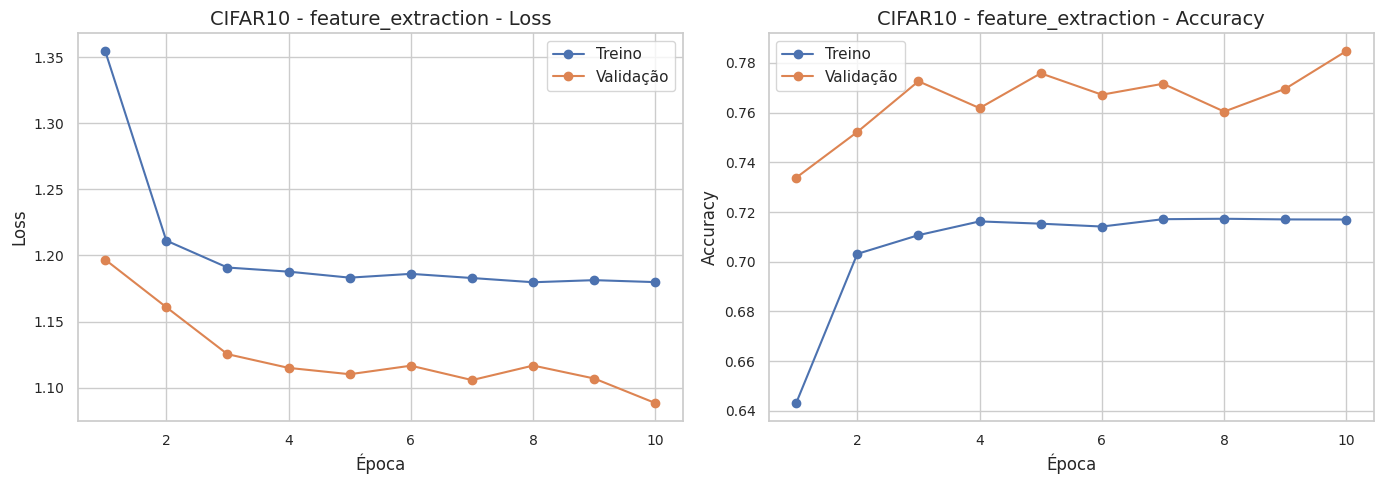

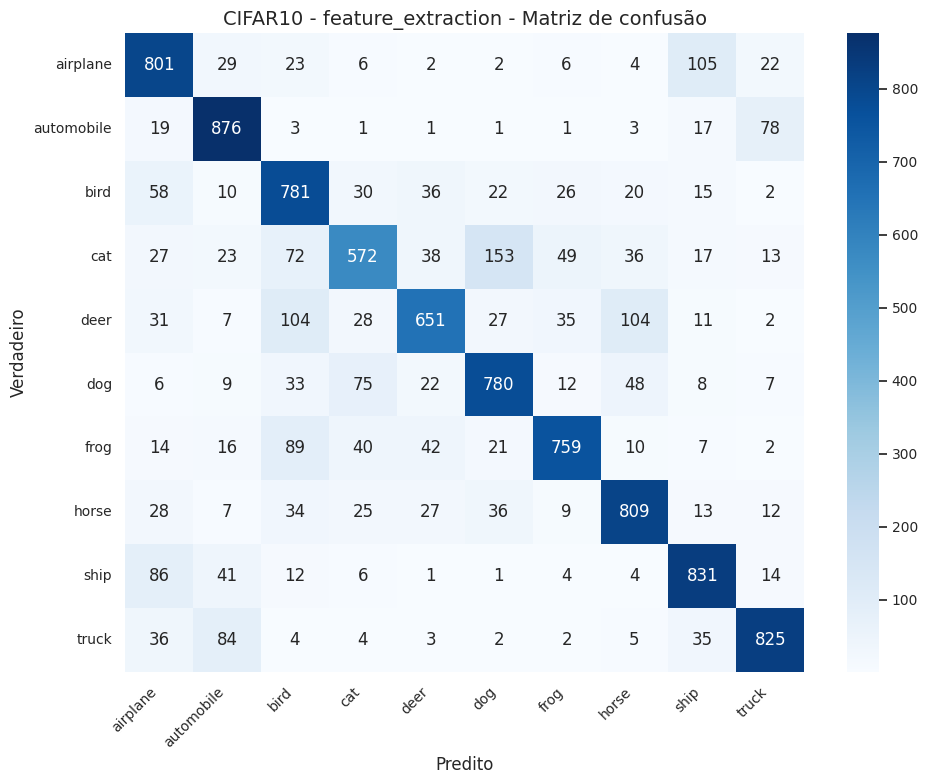

              precision    recall  f1-score   support

    airplane       0.72      0.80      0.76      1000
  automobile       0.79      0.88      0.83      1000
        bird       0.68      0.78      0.72      1000
         cat       0.73      0.57      0.64      1000
        deer       0.79      0.65      0.71      1000
         dog       0.75      0.78      0.76      1000
        frog       0.84      0.76      0.80      1000
       horse       0.78      0.81      0.79      1000
        ship       0.78      0.83      0.81      1000
       truck       0.84      0.82      0.83      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000

Top confusões: [(153, 'cat', 'dog'), (105, 'airplane', 'ship'), (104, 'deer', 'bird'), (104, 'deer', 'horse'), (89, 'frog', 'bird')]

===== CIFAR10 | fine_tuning =====
Total de parâmetros: 23,528,522
Parâmetros treináveis: 22,083,594


/tmp/ipykernel_1263/3646487847.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Treino:   0%|          | 0/704 [00:00<?, ?it/s]

Validação:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/10 | train_loss=0.8637 | train_acc=0.8524 | val_loss=0.6798 | val_acc=0.9272 | patience=0/3


...

Epoch 08/10 | train_loss=0.5633 | train_acc=0.9784 | val_loss=0.6411 | val_acc=0.9440 | patience=2/3


Treino:   0%|          | 0/704 [00:00<?, ?it/s]

Validação:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 09/10 | train_loss=0.5593 | train_acc=0.9798 | val_loss=0.6340 | val_acc=0.9448 | patience=3/3
Early stopping acionado com base em val_loss.


Validação:   0%|          | 0/157 [00:00<?, ?it/s]

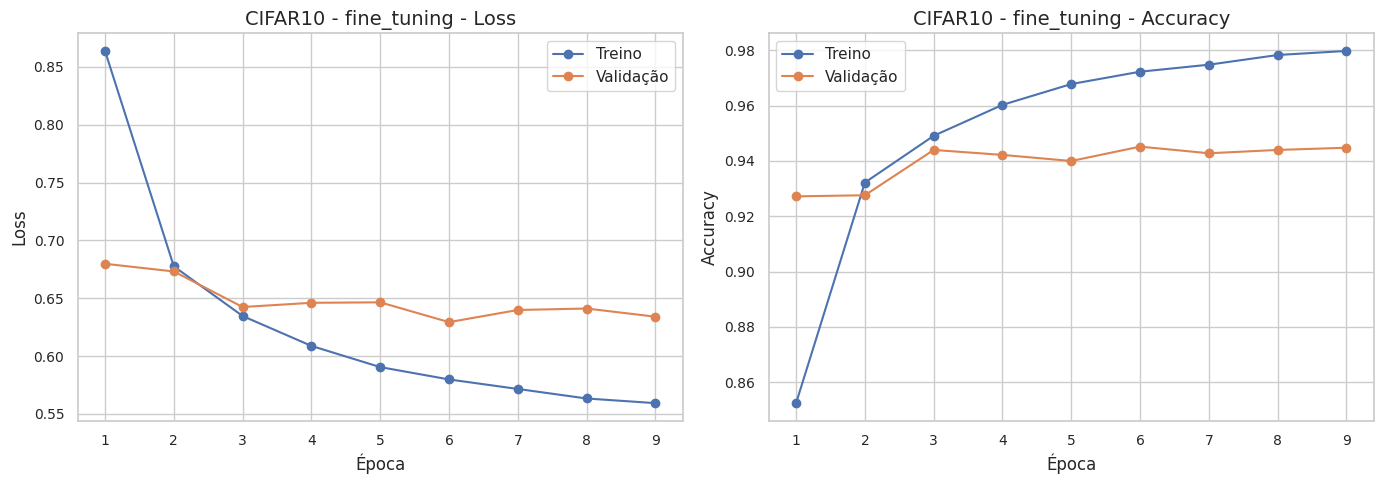

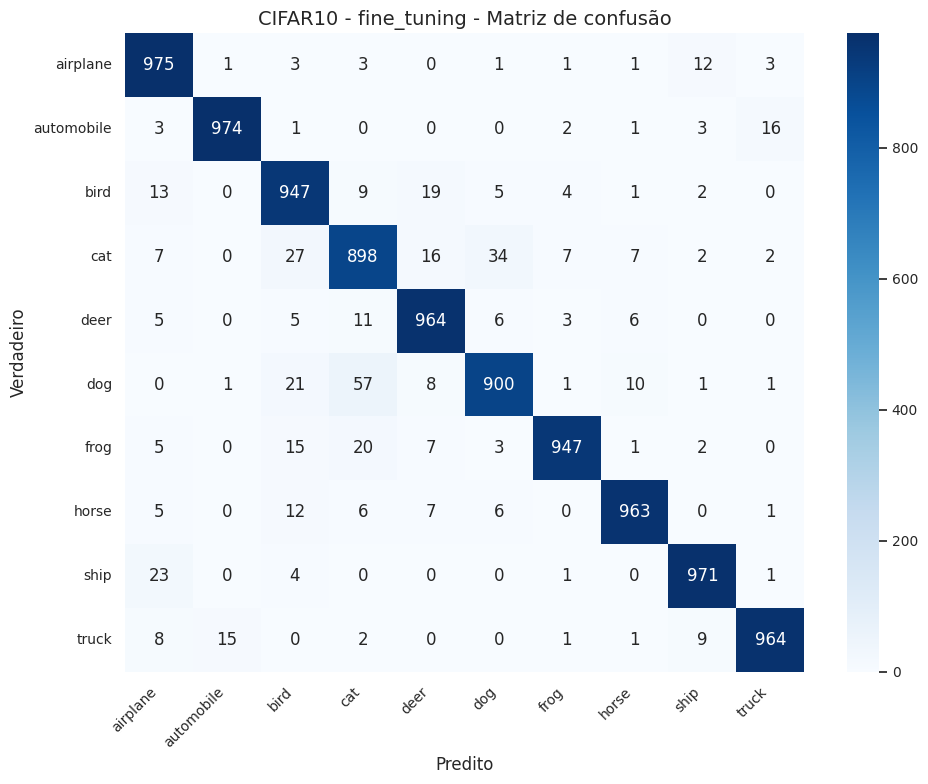

              precision    recall  f1-score   support

    airplane       0.93      0.97      0.95      1000
  automobile       0.98      0.97      0.98      1000
        bird       0.91      0.95      0.93      1000
         cat       0.89      0.90      0.90      1000
        deer       0.94      0.96      0.95      1000
         dog       0.94      0.90      0.92      1000
        frog       0.98      0.95      0.96      1000
       horse       0.97      0.96      0.97      1000
        ship       0.97      0.97      0.97      1000
       truck       0.98      0.96      0.97      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000

Top confusões: [(57, 'dog', 'cat'), (34, 'cat', 'dog'), (27, 'cat', 'bird'), (23, 'ship', 'airplane'), (21, 'dog', 'bird')]

===== EUROSAT | feature_extraction =====


100%|██████████| 94.3M/94.3M [00:00<00:00, 421MB/s]


Total de parâmetros: 23,528,522
Parâmetros treináveis: 20,490


/tmp/ipykernel_1263/3646487847.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Treino:   0%|          | 0/338 [00:00<?, ?it/s]

...

Epoch 09/10 | train_loss=0.8839 | train_acc=0.8616 | val_loss=0.8723 | val_acc=0.8748 | patience=1/3


Treino:   0%|          | 0/338 [00:00<?, ?it/s]

Validação:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=0.8876 | train_acc=0.8592 | val_loss=0.8508 | val_acc=0.8889 | patience=0/3


Validação:   0%|          | 0/43 [00:00<?, ?it/s]

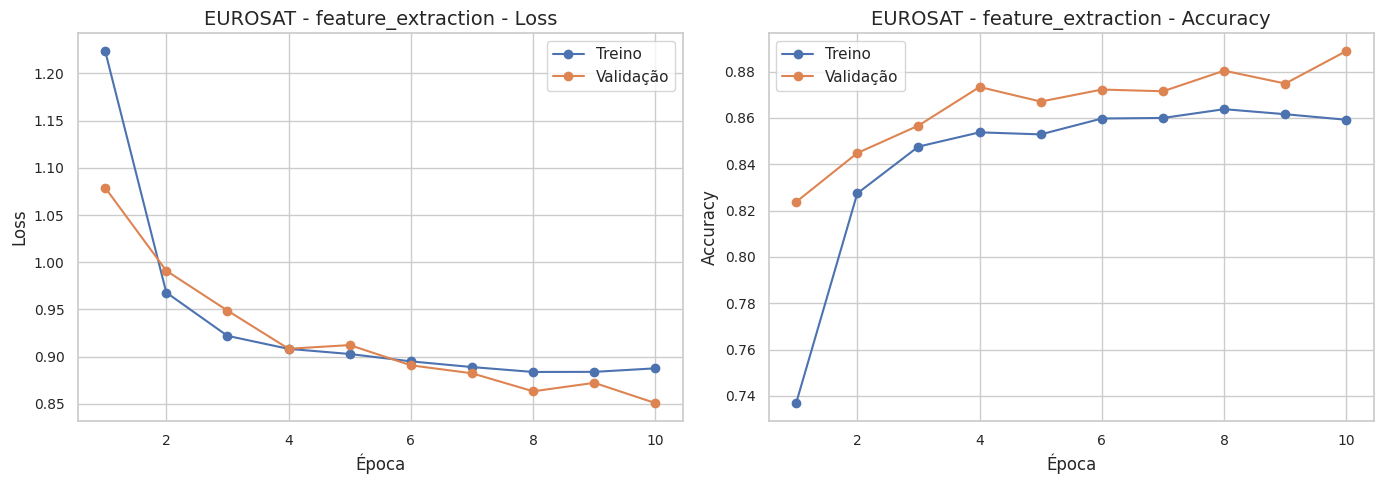

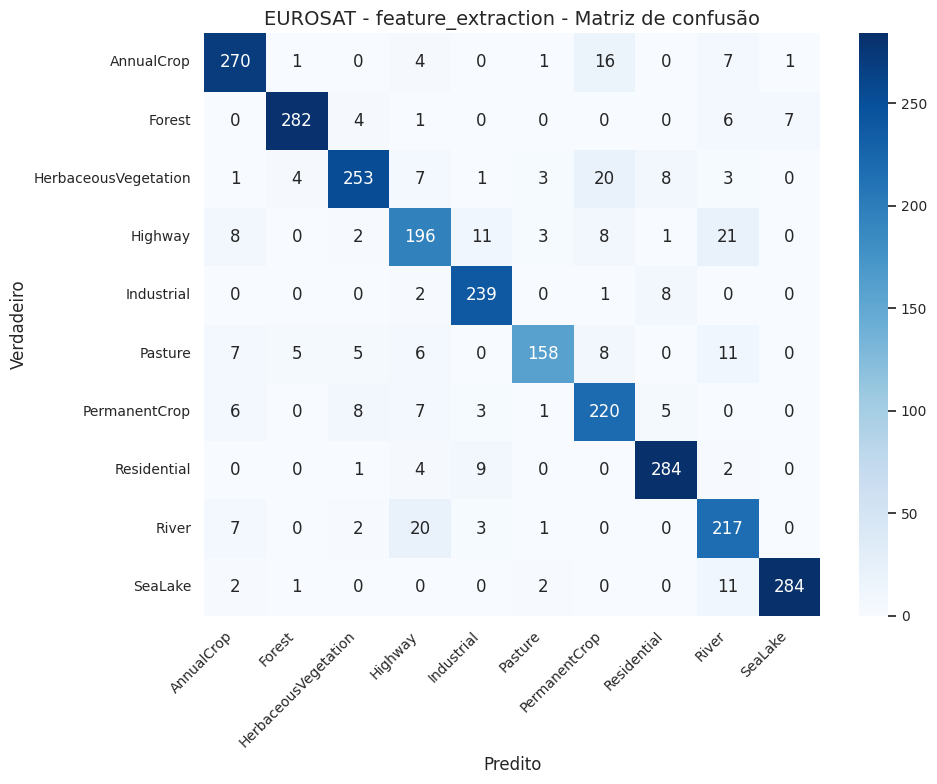

                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.90      0.90       300
              Forest       0.96      0.94      0.95       300
HerbaceousVegetation       0.92      0.84      0.88       300
             Highway       0.79      0.78      0.79       250
          Industrial       0.90      0.96      0.93       250
             Pasture       0.93      0.79      0.86       200
       PermanentCrop       0.81      0.88      0.84       250
         Residential       0.93      0.95      0.94       300
               River       0.78      0.87      0.82       250
             SeaLake       0.97      0.95      0.96       300

            accuracy                           0.89      2700
           macro avg       0.89      0.89      0.89      2700
        weighted avg       0.89      0.89      0.89      2700

Top confusões: [(21, 'Highway', 'River'), (20, 'HerbaceousVegetation', 'PermanentCrop'), (20, 'River', 'Highway'), (16, 'AnnualCr

/tmp/ipykernel_1263/3646487847.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Treino:   0%|          | 0/338 [00:00<?, ?it/s]

Validação:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 01/10 | train_loss=0.7848 | train_acc=0.8925 | val_loss=0.6111 | val_acc=0.9589 | patience=0/3


...

Epoch 09/10 | train_loss=0.5620 | train_acc=0.9789 | val_loss=0.5636 | val_acc=0.9778 | patience=2/3


Treino:   0%|          | 0/338 [00:00<?, ?it/s]

Validação:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=0.5572 | train_acc=0.9819 | val_loss=0.5508 | val_acc=0.9841 | patience=0/3


Validação:   0%|          | 0/43 [00:00<?, ?it/s]

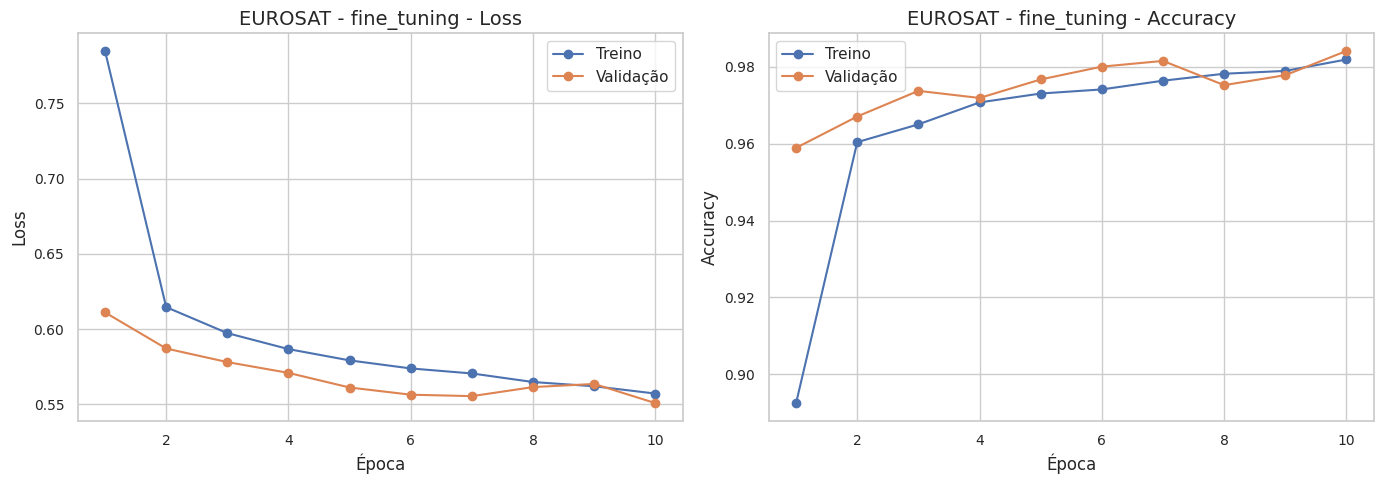

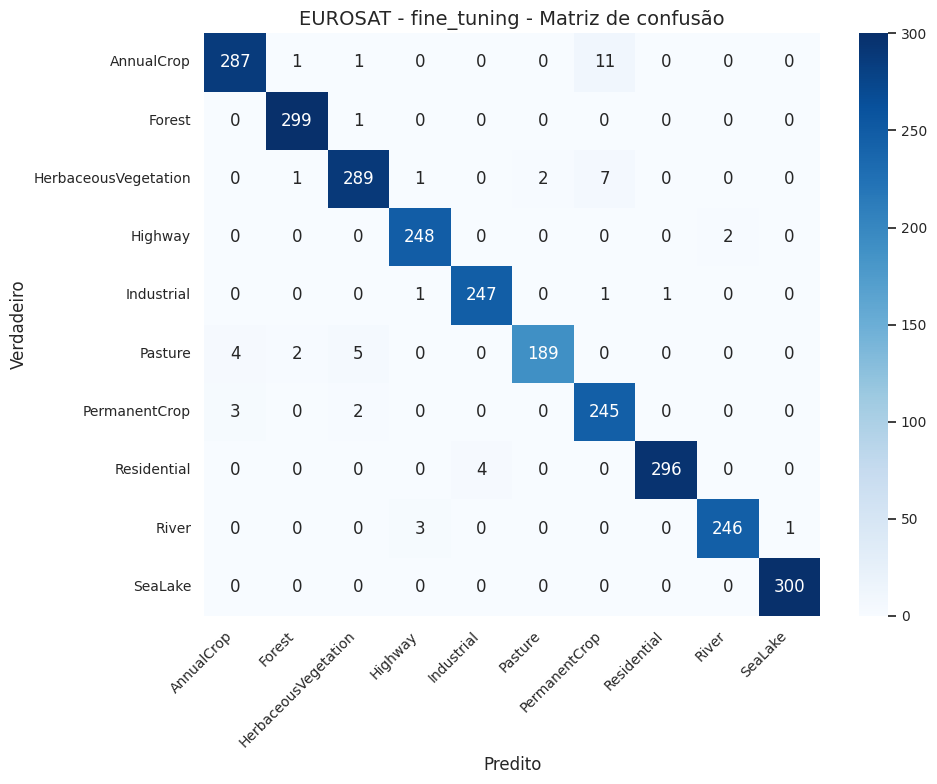

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.96      0.97       300
              Forest       0.99      1.00      0.99       300
HerbaceousVegetation       0.97      0.96      0.97       300
             Highway       0.98      0.99      0.99       250
          Industrial       0.98      0.99      0.99       250
             Pasture       0.99      0.94      0.97       200
       PermanentCrop       0.93      0.98      0.95       250
         Residential       1.00      0.99      0.99       300
               River       0.99      0.98      0.99       250
             SeaLake       1.00      1.00      1.00       300

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700

Top confusões: [(11, 'AnnualCrop', 'PermanentCrop'), (7, 'HerbaceousVegetation', 'PermanentCrop'), (5, 'Pasture', 'HerbaceousVege

,dataset,strategy,test_accuracy,test_f1_macro,best_val_loss,trainable_params,total_params,training_time_sec,epochs_ran,test_accuracy_pct,test_f1_macro_pct,training_time_min
0,cifar10,feature_extraction,0.7685,0.766767,1.088293,20490,23528522,3024.837146,10,76.85,76.68,50.41
1,cifar10,fine_tuning,0.9503,0.950323,0.629322,22083594,23528522,2882.294547,9,95.03,95.03,48.04
2,eurosat,feature_extraction,0.8900,0.886108,0.850766,20490,23528522,1661.453227,10,89.00,88.61,27.69
3,eurosat,fine_tuning,0.9800,0.979468,0.550842,22083594,23528522,1740.068197,10,98.00,97.95,29.00


In [5]:
def run_experiment(dataset_name: str, strategy: str):
    print(f'\n===== {dataset_name.upper()} | {strategy} =====')

    train_dataset, val_dataset, test_dataset, class_names = build_datasets(dataset_name)
    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset, shuffle=False)
    test_loader = make_loader(test_dataset, shuffle=False)

    model = build_resnet50_model(num_classes=len(class_names), strategy=strategy)
    trainable_params = count_trainable_params(model)
    total_params = sum(parameter.numel() for parameter in model.parameters())

    print(f'Total de parâmetros: {total_params:,}')
    print(f'Parâmetros treináveis: {trainable_params:,}')

    model, history_df, total_time, best_val_loss = train_model(
        model,
        train_loader,
        val_loader,
        strategy=strategy,
        num_epochs=NUM_EPOCHS,
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    test_metrics = evaluate_model(model, test_loader, criterion)

    cm = confusion_matrix(test_metrics['targets'], test_metrics['preds'], labels=list(range(len(class_names))))
    report = classification_report(test_metrics['targets'], test_metrics['preds'], target_names=class_names, zero_division=0)
    top_errors = top_confusions(cm, class_names, top_k=5)

    experiment_dir = OUTPUT_ROOT / dataset_name / strategy
    experiment_dir.mkdir(parents=True, exist_ok=True)

    history_path = experiment_dir / 'history.csv'
    summary_path = experiment_dir / 'summary.txt'
    curve_path = experiment_dir / 'curves.png'
    cm_path = experiment_dir / 'confusion_matrix.png'

    history_df.to_csv(history_path, index=False)
    plot_history(history_df, f'{dataset_name.upper()} - {strategy}', save_path=curve_path)
    plot_confusion_matrix(cm, class_names, f'{dataset_name.upper()} - {strategy} - Matriz de confusão', save_path=cm_path)

    with open(summary_path, 'w', encoding='utf-8') as file_handle:
        file_handle.write(f'Dataset: {dataset_name}\n')
        file_handle.write(f'Strategy: {strategy}\n')
        file_handle.write(f'Total params: {total_params}\n')
        file_handle.write(f'Trainable params: {trainable_params}\n')
        file_handle.write(f'Total time (s): {total_time:.2f}\n')
        file_handle.write(f'Best val loss: {best_val_loss:.4f}\n')
        file_handle.write(f'Test loss: {test_metrics["loss"]:.4f}\n')
        file_handle.write(f'Test accuracy: {test_metrics["accuracy"]:.4f}\n')
        file_handle.write(f'Test f1_macro: {test_metrics["f1_macro"]:.4f}\n\n')
        file_handle.write('Classification report:\n')
        file_handle.write(report)
        file_handle.write('\n\nTop confusions:\n')
        for count, true_class, pred_class in top_errors:
            file_handle.write(f'{true_class} -> {pred_class}: {count}\n')

    result = {
        'dataset': dataset_name,
        'strategy': strategy,
        'test_accuracy': test_metrics['accuracy'],
        'test_f1_macro': test_metrics['f1_macro'],
        'best_val_loss': best_val_loss,
        'trainable_params': trainable_params,
        'total_params': total_params,
        'training_time_sec': total_time,
        'epochs_ran': len(history_df),
        'history_path': str(history_path),
        'curve_path': str(curve_path),
        'cm_path': str(cm_path),
        'summary_path': str(summary_path),
        'top_confusions': top_errors,
        'class_names': class_names,
        'history_df': history_df,
        'confusion_matrix': cm,
        'classification_report': report,
    }

    print(report)
    print('Top confusões:', top_errors)

    return result


EXPERIMENTS = [
    ('cifar10', 'feature_extraction'),
    ('cifar10', 'fine_tuning'),
    ('eurosat', 'feature_extraction'),
    ('eurosat', 'fine_tuning'),
]

results = []
for dataset_name, strategy in EXPERIMENTS:
    result = run_experiment(dataset_name, strategy)
    results.append(result)

results_df = pd.DataFrame([{
    'dataset': item['dataset'],
    'strategy': item['strategy'],
    'test_accuracy': item['test_accuracy'],
    'test_f1_macro': item['test_f1_macro'],
    'best_val_loss': item['best_val_loss'],
    'trainable_params': item['trainable_params'],
    'total_params': item['total_params'],
    'training_time_sec': item['training_time_sec'],
    'epochs_ran': item['epochs_ran'],
} for item in results])

results_df['test_accuracy_pct'] = (results_df['test_accuracy'] * 100).round(2)
results_df['test_f1_macro_pct'] = (results_df['test_f1_macro'] * 100).round(2)
results_df['training_time_min'] = (results_df['training_time_sec'] / 60).round(2)

results_df = results_df.sort_values(['dataset', 'strategy']).reset_index(drop=True)
results_df

In [6]:
summary_table = results_df[[
    'dataset',
    'strategy',
    'test_accuracy_pct',
    'test_f1_macro_pct',
    'training_time_min',
    'trainable_params',
]].copy()

summary_table.columns = [
    'dataset',
    'strategy',
    'test_accuracy_%',
    'test_f1_macro_%',
    'training_time_min',
    'trainable_params',
]

display(summary_table)

summary_csv = OUTPUT_ROOT / 'summary_results.csv'
summary_table.to_csv(summary_csv, index=False)
print(f'Summary saved to: {summary_csv}')

for item in results:
    dataset_name = item['dataset']
    strategy = item['strategy']
    print('\n' + '=' * 80)
    print(f'{dataset_name.upper()} | {strategy}')
    print(f'Accuracy: {item["test_accuracy"]:.4f}')
    print(f'F1 macro: {item["test_f1_macro"]:.4f}')
    print(f'Time (min): {item["training_time_sec"] / 60:.2f}')
    print(f'Trainable params: {item["trainable_params"]:,}')
    print('Top confusions:', item['top_confusions'])

gain_rows = []
for dataset_name in results_df['dataset'].unique():
    subset = results_df[results_df['dataset'] == dataset_name].set_index('strategy')
    if {'feature_extraction', 'fine_tuning'}.issubset(subset.index):
        gain_rows.append({
            'dataset': dataset_name,
            'accuracy_gain_pct_points': (subset.loc['fine_tuning', 'test_accuracy_pct'] - subset.loc['feature_extraction', 'test_accuracy_pct']).round(2),
            'f1_gain_pct_points': (subset.loc['fine_tuning', 'test_f1_macro_pct'] - subset.loc['feature_extraction', 'test_f1_macro_pct']).round(2),
        })

gain_table = pd.DataFrame(gain_rows)
display(gain_table)

gain_csv = OUTPUT_ROOT / 'fine_tuning_gain.csv'
gain_table.to_csv(gain_csv, index=False)
print(f'Gain table saved to: {gain_csv}')

,dataset,strategy,test_accuracy_%,test_f1_macro_%,training_time_min,trainable_params
0,cifar10,feature_extraction,76.85,76.68,50.41,20490
1,cifar10,fine_tuning,95.03,95.03,48.04,22083594
2,eurosat,feature_extraction,89.00,88.61,27.69,20490
3,eurosat,fine_tuning,98.00,97.95,29.00,22083594


Summary saved to: /content/transfer_learning_results/summary_results.csv

CIFAR10 | feature_extraction
Accuracy: 0.7685
F1 macro: 0.7668
Time (min): 50.41
Trainable params: 20,490
Top confusions: [(153, 'cat', 'dog'), (105, 'airplane', 'ship'), (104, 'deer', 'bird'), (104, 'deer', 'horse'), (89, 'frog', 'bird')]

CIFAR10 | fine_tuning
Accuracy: 0.9503
F1 macro: 0.9503
Time (min): 48.04
Trainable params: 22,083,594
Top confusions: [(57, 'dog', 'cat'), (34, 'cat', 'dog'), (27, 'cat', 'bird'), (23, 'ship', 'airplane'), (21, 'dog', 'bird')]

EUROSAT | feature_extraction
Accuracy: 0.8900
F1 macro: 0.8861
Time (min): 27.69
Trainable params: 20,490
Top confusions: [(21, 'Highway', 'River'), (20, 'HerbaceousVegetation', 'PermanentCrop'), (20, 'River', 'Highway'), (16, 'AnnualCrop', 'PermanentCrop'), (11, 'Highway', 'Industrial')]

EUROSAT | fine_tuning
Accuracy: 0.9800
F1 macro: 0.9795
Time (min): 29.00
Trainable params: 22,083,594
Top confusions: [(11, 'AnnualCrop', 'PermanentCrop'), (7, 'Her

,dataset,accuracy_gain_pct_points,f1_gain_pct_points
0,cifar10,18.18,18.35
1,eurosat,9.00,9.34


Gain table saved to: /content/transfer_learning_results/fine_tuning_gain.csv
